In [1]:
# Level 5: Visualization and Basic Prediction

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
.appName("TrainSchedulePipeline") \
.master("local[*]") \
.getOrCreate()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

df = pd.read_csv("/home/jovyan/work/transformed_data.csv")

stops_table = pd.read_csv("/home/jovyan/work/stops_table.csv")

distance_table = pd.read_csv("/home/jovyan/work/distance_table.csv")

print("All Datasets Loaded")

All Datasets Loaded


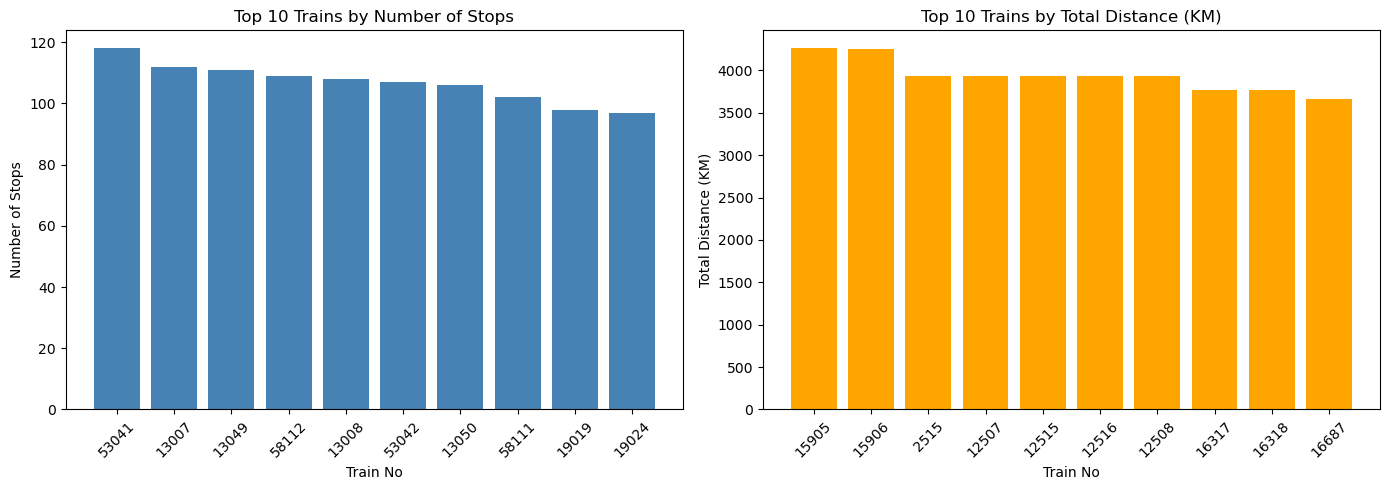

In [4]:
# Task 5.1 - Create charts to visualize train stops and total distance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Chart 1 - Top 10 Trains by Number of Stops
top_stops = stops_table.head(10)
axes[0].bar(
    top_stops['Train_No'].astype(str),
    top_stops['Number_of_Stops'],
    color='steelblue'
)
axes[0].set_title('Top 10 Trains by Number of Stops')
axes[0].set_xlabel('Train No')
axes[0].set_ylabel('Number of Stops')
axes[0].tick_params(axis='x', rotation=45)

# -- Chart 2 - Top 10 Trains by Total Distance
top_distance = distance_table.head(10)
axes[1].bar(
    top_distance['Train_No'].astype(str),
    top_distance['Total_distance_KM'],
    color='orange'
)
axes[1].set_title('Top 10 Trains by Total Distance (KM)')
axes[1].set_xlabel('Train No')
axes[1].set_ylabel('Total Distance (KM)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/home/jovyan/work/stops_distance_chart.png")
plt.show()

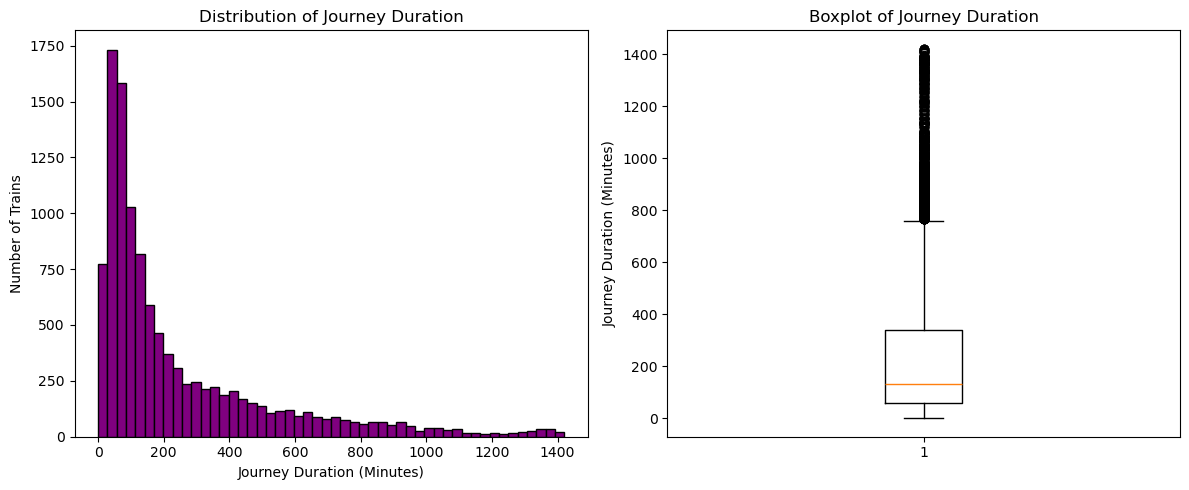

In [5]:
# Task 5.2 - Visualize the distribution of journey duration

journey_duration = df.groupby('Train_No')['journey_duration_min'] \
    .first().reset_index()

plt.figure(figsize=(12, 5))

# -- Histogram
plt.subplot(1, 2, 1)
plt.hist(
    journey_duration['journey_duration_min'],
    bins=50,
    color='purple',
    edgecolor='black'
)
plt.title('Distribution of Journey Duration')
plt.xlabel('Journey Duration (Minutes)')
plt.ylabel('Number of Trains')

# -- Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(journey_duration['journey_duration_min'])
plt.title('Boxplot of Journey Duration')
plt.ylabel('Journey Duration (Minutes)')

plt.tight_layout()
plt.savefig("/home/jovyan/work/journey_duration_chart.png")
plt.show()

In [6]:
# Task 5.3 - Split the dataset into training and testing subsets

from sklearn.model_selection import train_test_split

# -- Prepare features
journey_data = df.groupby('Train_No').agg(
    num_stops=('Station_Name', 'count'),
    total_distance=('Distance', 'max'),
    journey_duration_min=('journey_duration_min', 'first')
).reset_index()

# -- Features and Target
X = journey_data[['num_stops', 'total_distance']]
y = journey_data['journey_duration_min']

# -- Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train Test Split Done")
print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

Train Test Split Done
Training Size: 8890
Testing Size: 2223


In [7]:
# Task 5.4 - Build a simple predictive model to estimate journey duration

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# -- Build model
model = LinearRegression()
model.fit(X_train, y_train)

# -- Predict
y_pred = model.predict(X_test)

# -- Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Built")
print("=" * 40)
print("Model Performance:")
print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))
print("=" * 40)

Linear Regression Model Built
Model Performance:
Mean Absolute Error: 166.32
R2 Score: 0.21
